In [27]:
# Standard libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
# Train-test and preprocessing functions
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Classifiers
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
# Metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score




In [28]:
filename = "/Users/ekaterinaleontieva/test/diabetes.csv"
diabetes = pd.read_csv(filename)


In [29]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
diabetes.shape


(768, 9)

In [31]:
for name in diabetes.keys()[1:-1]:
    diabetes[name] = diabetes[name].replace({0: np.nan})

In [32]:
diabetes = diabetes.dropna()

In [33]:
diabetes.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [34]:
df = diabetes.drop(columns=['SkinThickness', 'Insulin'])
df = df.dropna()

In [35]:
X = df[df.keys()[0:-1]]
y = df[df.keys()[-1]]
(n,p) = X.shape
print('n =', n, ', p =', p)

X_train, X_test, y_train, y_test = \
train_test_split(X, y, test_size=0.25, random_state=12)

n = 392 , p = 6


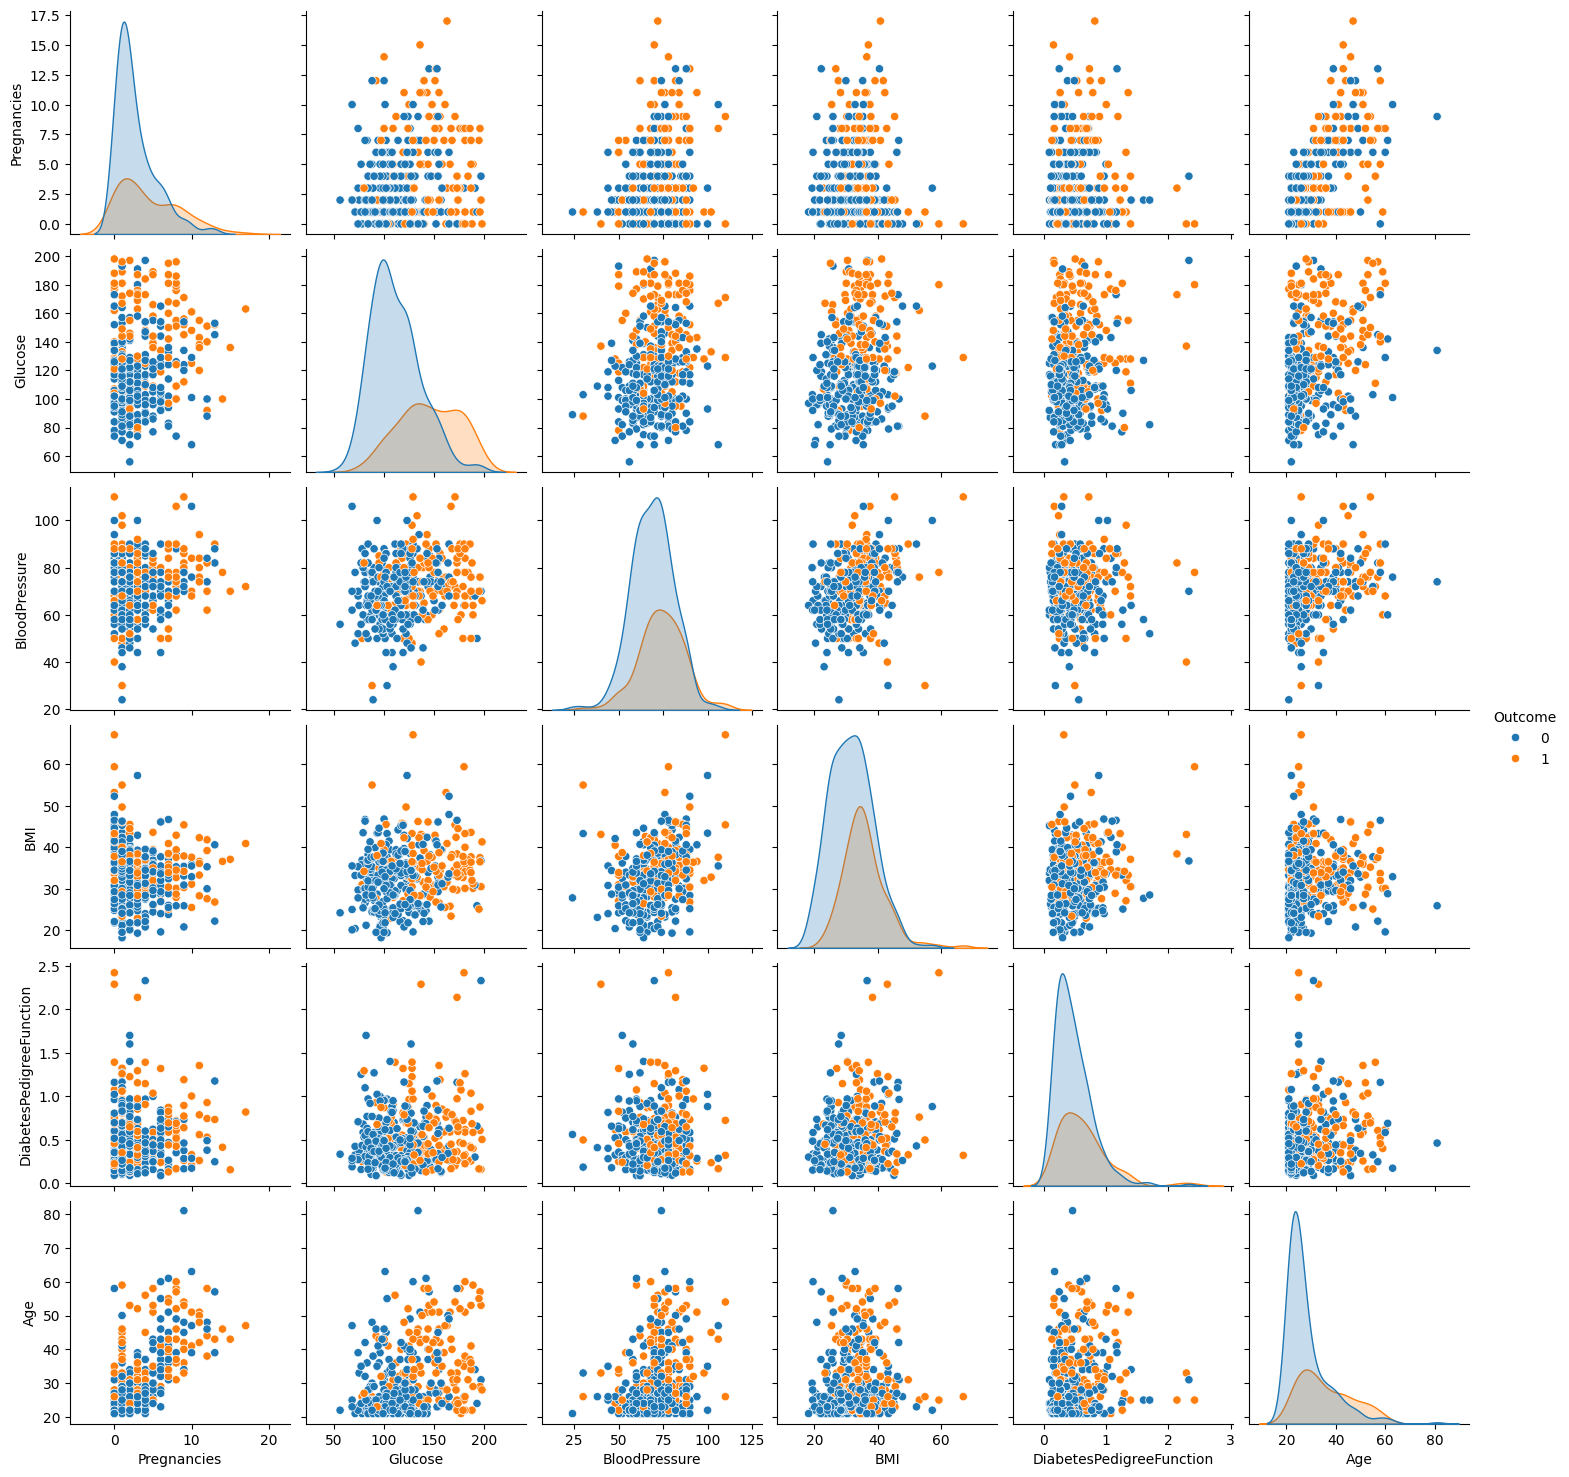

In [36]:
sns.pairplot(df, hue='Outcome')
plt.show()

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "NaiveBayes": GaussianNB(),
    "LogisticRegression": LogisticRegression()
}

In [40]:
for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    print("------", name, "------")
    
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Train Confusion Matrix")
    print(confusion_matrix(y_train, y_train_pred))
    print("Test Confusion Matrix")
    print(confusion_matrix(y_test, y_test_pred))

------ LDA ------
Train Accuracy: 0.7789115646258503
Test Accuracy: 0.826530612244898
Train Confusion Matrix
[[169  23]
 [ 42  60]]
Test Confusion Matrix
[[65  5]
 [12 16]]
------ QDA ------
Train Accuracy: 0.8061224489795918
Test Accuracy: 0.7653061224489796
Train Confusion Matrix
[[169  23]
 [ 34  68]]
Test Confusion Matrix
[[60 10]
 [13 15]]
------ NaiveBayes ------
Train Accuracy: 0.7789115646258503
Test Accuracy: 0.7755102040816326
Train Confusion Matrix
[[161  31]
 [ 34  68]]
Test Confusion Matrix
[[59 11]
 [11 17]]
------ LogisticRegression ------
Train Accuracy: 0.7721088435374149
Test Accuracy: 0.8061224489795918
Train Confusion Matrix
[[169  23]
 [ 44  58]]
Test Confusion Matrix
[[64  6]
 [13 15]]


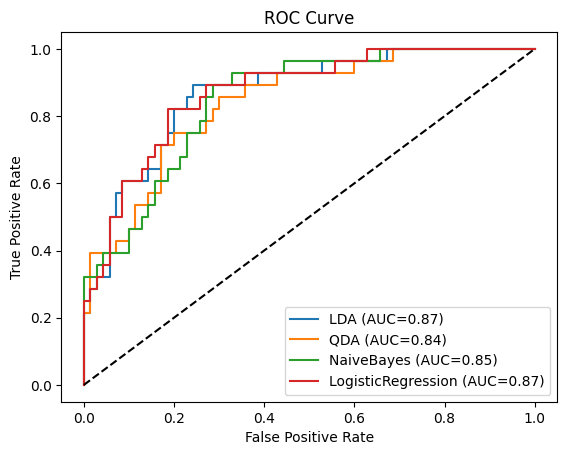

In [41]:
plt.figure()

for name, model in models.items():
    
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [42]:
X['BMI_Age'] = X['BMI'] * X['Age']
X['Glucose_BMI'] = X['Glucose'] * X['BMI']